# Example Usage

This notebook walks through every plot function using two sets of TextGrid files.
They come from the same dataset: one alignment set is produced by [MFA](https://github.com/MontrealCorpusTools/Montreal-Forced-Aligner) and the other by [W2TG](https://github.com/pkadambi/Wav2TextGrid).

All plot functions implement the `PlotFunction` protocol defined in [`src/alignment_comparison_plots/_types.py`](../src/alignment_comparison_plots/_types.py).

## 1. Imports

In [1]:
import glob

from alignment_comparison_plots import (
    plot_phoneme_counts,
    plot_phoneme_overlap,
    plot_phoneme_overlap_rate,
    plot_phoneme_pair_scatter,
)

## 2. Configure paths and shared kwargs

> **Note:** The library does not validate paths or data pairs. Validate your path lists before plotting; the right checks depend on your use case. The cell below shows a minimal example.

In [2]:
# ── Edit these paths to point at your own TextGrid directories ──────────────
DATASET = "/Users/beckettfrey/.voxkit/datasets/20260310_144753_819272/"
ALIGNMENT_A = f"{DATASET}/alignments/20260310_144925_055142/textgrids/cache"
ALIGNMENT_B = f"{DATASET}/alignments/20260310_144806_088416/textgrids/cache"
# ────────────────────────────────────────────────────────────────────────────

paths_a = glob.glob(f"{ALIGNMENT_A}/*/*.TextGrid")
paths_b = glob.glob(f"{ALIGNMENT_B}/*/*.TextGrid")

print(f"Set A: {len(paths_a)} files")
print(f"Set B: {len(paths_b)} files")

if len(paths_a) != len(paths_b):
    print("Warning: The two sets have different numbers of files. Make sure they are aligned properly.")
    
speakers_a = set(p.split("/")[-2] for p in paths_a)
speakers_b = set(p.split("/")[-2] for p in paths_b)

print(f"Speakers in A: {len(speakers_a)}")
print(f"Speakers in B: {len(speakers_b)}")

if speakers_a != speakers_b:
    print("Warning: The two sets have different speakers. Make sure they are aligned properly.")

Set A: 181 files
Set B: 181 files
Speakers in A: 3
Speakers in B: 3


In [3]:
from alignment_comparison_plots._types import PlotFunction

# All plotting functions share these arguments, so we can define them once here.
SHARED: PlotFunction = dict(
    paths_a=paths_a,
    paths_b=paths_b,
    label_a="W2TG Reference",
    label_b="MFA Hypothesis",
    aggregate_emphasis=True,  # strip stress markers: AH1 → AH
    exec_=False,
)

## 3. Phoneme counts

Side-by-side bar chart showing how many times each phoneme appears in each alignment set.
Useful for verifying that both aligners produce similar phoneme distributions.

qt.qpa.fonts: Populating font family aliases took 60 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


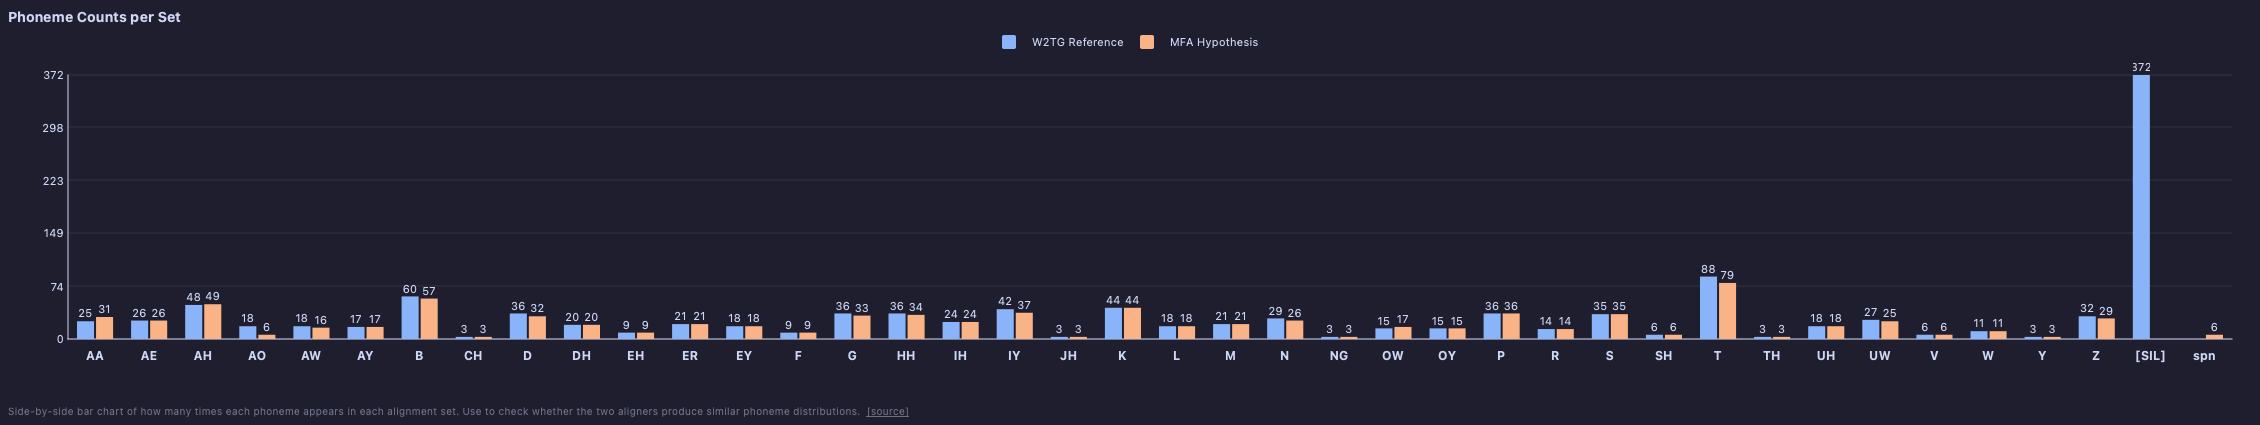

In [4]:
plot_phoneme_counts(**SHARED, save_png="../docs/img/plot_phoneme_counts.png")

## 4. Phoneme overlap (mean IoU)

For each reference interval the best same-label hypothesis interval is scored with IoU.
Bars are sorted left→right by ascending mean IoU and coloured red (poor) → green (perfect).

qt.qpa.fonts: Populating font family aliases took 10 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


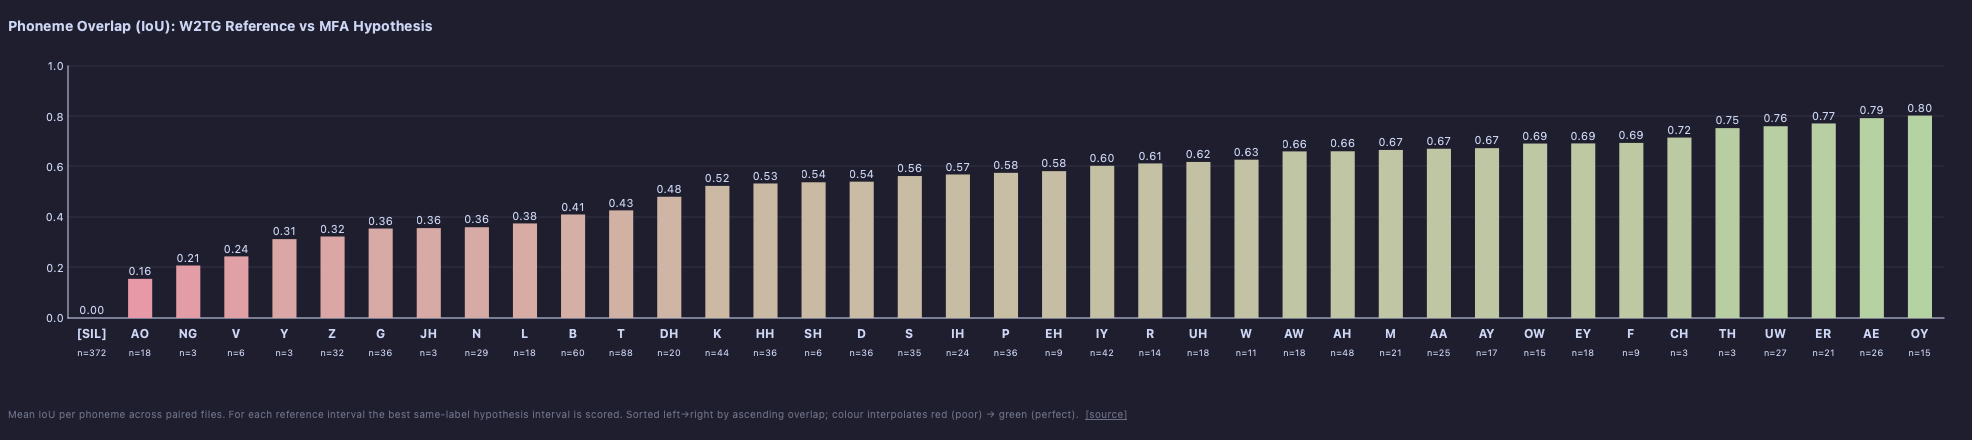

In [5]:
plot_phoneme_overlap(**SHARED, save_png="../docs/img/plot_phoneme_overlap.png")

## 5. Phoneme overlap rate

Percentage of reference intervals whose best same-label hypothesis match has IoU ≥ `threshold`.
Adjust `threshold` to tighten or loosen what counts as a successful match.

qt.qpa.fonts: Populating font family aliases took 11 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


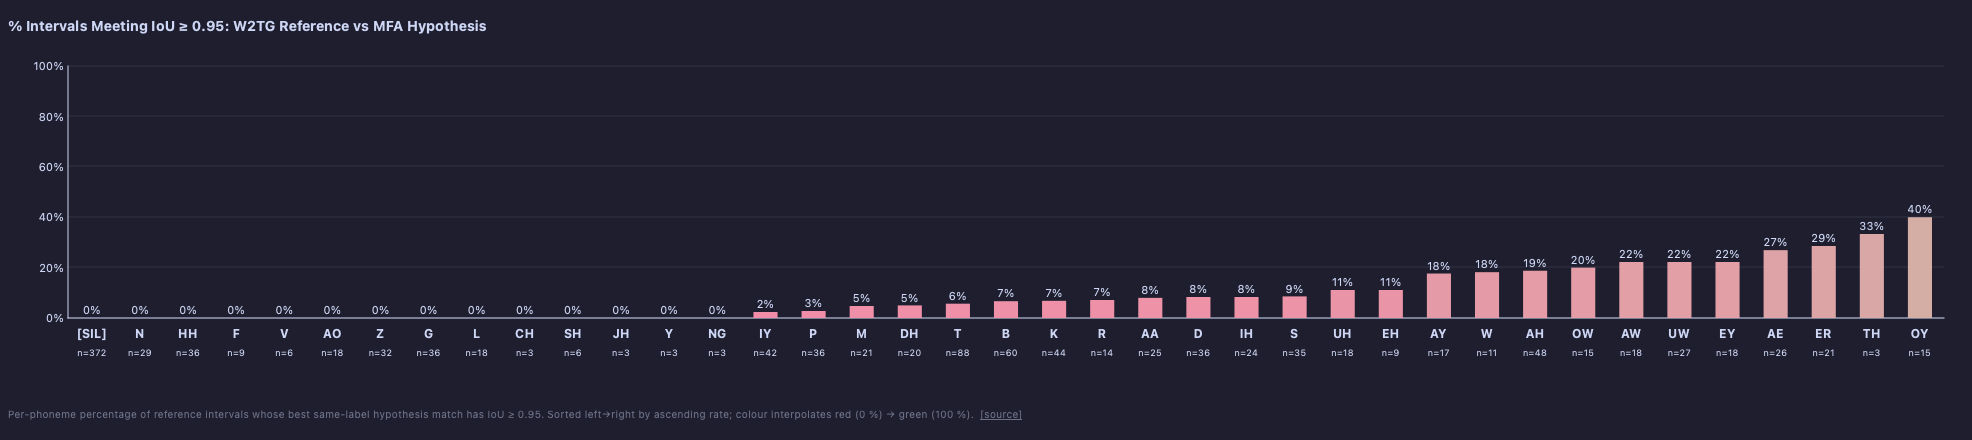

In [6]:
plot_phoneme_overlap_rate(**SHARED, threshold=0.95, save_png="../docs/img/plot_phoneme_overlap_rate.png")

## 6. Phoneme pair scatter

Grid of (reference phoneme, hypothesis phoneme) pairs.
Bubble size ∝ observation count; colour = mean IoU.
On-diagonal bubbles indicate label agreement; off-diagonal bubbles indicate substitutions.

qt.qpa.fonts: Populating font family aliases took 11 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


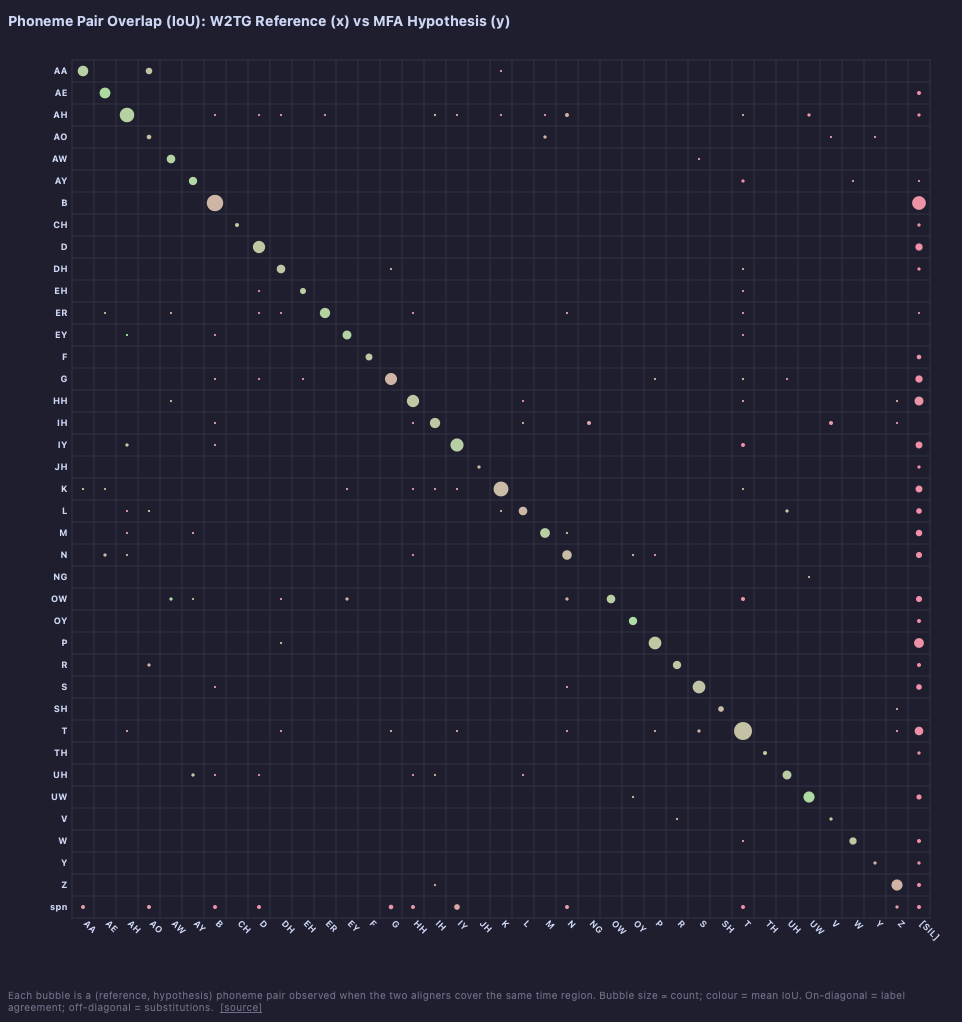

In [7]:
plot_phoneme_pair_scatter(**SHARED, save_png="../docs/img/plot_phoneme_pair_scatter.png")